Iteration 1

In [ ]:
# =========================
# IMPORTS
# =========================
import os
import gc
import json
import shutil
import numpy as np
import librosa
from pathlib import Path
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
DATA_DIR = "./data"
SAVE_DIR      = "./results"
TEMP_DIR      = "./temp_preprocessed"

SR            = 16000
DURATION      = 3
N_FFT         = 2048
HOP_LENGTH    = 306
N_MELS        = 256
TARGET_FRAMES = 157
FMAX          = 8000

TARGET_SAMPLES_PER_CLASS = 5000

os.makedirs(TEMP_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# =========================
# AUDIO UTILITIES
# =========================

def pad_audio(y, target_len):
    if len(y) >= target_len:
        return y[:target_len]
    pad_width = target_len - len(y)
    if pad_width > len(y):
        return np.pad(y, (0, pad_width), mode='edge')
    return np.pad(y, (0, pad_width), mode='reflect')

def preprocess_audio(file_path):
    try:
        y, _ = librosa.load(file_path, sr=SR)
    except Exception:
        return None
    if y is None or len(y) == 0:
        return None
    y, _ = librosa.effects.trim(y)
    if len(y) < SR * 0.5:
        return None
    if np.max(np.abs(y)) == 0:
        return None
    return y

def segment_audio(y, sr=SR, duration=DURATION):
    seg_len = int(sr * duration)
    hop_len = seg_len // 2
    if len(y) >= seg_len:
        segments = []
        for start in range(0, len(y) - seg_len + 1, hop_len):
            segments.append(y[start:start + seg_len])
        return segments
    else:
        return [pad_audio(y, seg_len)]
def segment_audio_tight(y, sr=SR, duration=DURATION):
    seg_len = int(sr * duration)
    hop_len = seg_len // 4
    if len(y) >= seg_len:
        segs = [y[s:s+seg_len] for s in range(0, len(y)-seg_len+1, hop_len)]
        return segs if segs else [pad_audio(y, seg_len)]
    return [pad_audio(y, seg_len)]

def spec_augment(spec, freq_mask=10, time_mask=10):
    spec       = spec.copy()
    mask_value = -80.0
    f  = np.random.randint(1, freq_mask + 1)
    f0 = np.random.randint(0, spec.shape[0] - f)
    spec[f0:f0 + f, :] = mask_value
    t  = np.random.randint(1, time_mask + 1)
    t0 = np.random.randint(0, spec.shape[1] - t)
    spec[:, t0:t0 + t] = mask_value
    return spec

def extract_logmel(y, apply_specaug=False):
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LENGTH, fmax=FMAX
    )
    log_mel = librosa.power_to_db(mel, ref=1.0)
    log_mel = np.clip(log_mel, a_min=-80, a_max=0)
    if log_mel.shape[1] < TARGET_FRAMES:
        log_mel = np.pad(log_mel, ((0, 0), (0, TARGET_FRAMES - log_mel.shape[1])))
    else:
        log_mel = log_mel[:, :TARGET_FRAMES]
    if apply_specaug:
        log_mel = spec_augment(log_mel)
    return log_mel[np.newaxis, :, :]

In [ ]:
# =========================
# AUGMENTATION
# =========================

def add_noise(y, snr_db):
    signal_power = np.mean(y ** 2) + 1e-8
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = np.random.normal(0, np.sqrt(noise_power), len(y))
    return y + noise

def gain_scale(y):
    return y * np.random.uniform(0.7, 1.3)

def time_stretch(y):
    rate      = np.random.uniform(0.9, 1.1)
    y_stretch = librosa.effects.time_stretch(y, rate=rate)
    return pad_audio(y_stretch, len(y))

def pitch_shift(y):
    n_steps = np.random.uniform(-2, 2)
    return librosa.effects.pitch_shift(y, sr=SR, n_steps=n_steps)

_AUGMENTATIONS = [
    lambda y: add_noise(y, snr_db=np.random.uniform(5, 20)),
    lambda y: gain_scale(y),
    lambda y: time_stretch(y),
    lambda y: pitch_shift(y),
    lambda y: add_noise(gain_scale(y),   snr_db=np.random.uniform(5, 20)),
    lambda y: add_noise(time_stretch(y), snr_db=np.random.uniform(5, 20)),
    lambda y: gain_scale(time_stretch(y)),
]

def augment_one(y):
    fn = _AUGMENTATIONS[np.random.randint(len(_AUGMENTATIONS))]
    return fn(y)

In [ ]:
# =========================
# MODEL & DATASET
# =========================

class ShipDataset(Dataset):
    """Memory-mapped dataset. shuffle_idx reorders data rows;
       labels[idx] (NOT labels[real_idx]) gives the correct label.
       FIX: was labels[real_idx] — wrong when shuffle_idx is used.
    """
    def __init__(self, mmap_path, labels, shuffle_idx=None):
        self.labels      = labels
        self.shuffle_idx = shuffle_idx
        self.data        = np.memmap(
            mmap_path, dtype='float32', mode='r',
            shape=(len(labels), 1, N_MELS, TARGET_FRAMES)
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        real_idx = self.shuffle_idx[idx] if self.shuffle_idx is not None else idx
        sample   = np.array(self.data[real_idx], copy=True)
        return torch.from_numpy(sample).float(), torch.tensor(self.labels[idx], dtype=torch.long)


class ShipCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1,   32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.2),
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.3),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.gap(self.conv_layers(x)))

---
## STEP 1 — Data Collection
Run **once**. Skip to the *Restore* cell on subsequent sessions.

In [ ]:
# =========================
# STEP 1 — DATA COLLECTION
# =========================
wav_files = list(Path(DATA_DIR).rglob("*.wav"))
print(f"Found {len(wav_files)} files.")

# Pass 1: count segments
print("Pass 1/2: counting segments...")
seg_counts, valid_files = [], []
for file_path in wav_files:
    signal = preprocess_audio(str(file_path))
    if signal is None:
        continue
    seg_counts.append(len(segment_audio(signal)))
    valid_files.append(file_path)

total_segments = sum(seg_counts)
print(f"Total segments: {total_segments}")

unique_label_names = sorted(set(p.parent.name for p in valid_files))
label_to_idx = {name: i for i, name in enumerate(unique_label_names)}
idx_to_label = {i: name for name, i in label_to_idx.items()}
print("Label mapping:", label_to_idx)

mmap_orig_path = os.path.join(TEMP_DIR, "X_orig_mmap.dat")
X_orig_mmap    = np.memmap(mmap_orig_path, dtype='float32', mode='w+',
                           shape=(total_segments, 1, N_MELS, TARGET_FRAMES))
y_orig         = np.empty(total_segments, dtype=np.int32)
file_ids_orig  = np.empty(total_segments, dtype=object)

# Pass 2: extract spectrograms
print("Pass 2/2: extracting spectrograms...")
write_idx = 0
for file_path, n_segs in tqdm(zip(valid_files, seg_counts), total=len(valid_files)):
    signal = preprocess_audio(str(file_path))
    if signal is None:
        continue
    label_idx = label_to_idx[file_path.parent.name]
    for seg in segment_audio(signal):
        X_orig_mmap[write_idx] = extract_logmel(seg, apply_specaug=False)
        y_orig[write_idx]      = label_idx
        file_ids_orig[write_idx] = str(file_path)
        write_idx += 1

X_orig_mmap.flush()

if write_idx < total_segments:
    print(f"  Trimmed {total_segments - write_idx} pre-allocated rows")
    X_orig_mmap    = X_orig_mmap[:write_idx]
    y_orig         = y_orig[:write_idx]
    file_ids_orig  = file_ids_orig[:write_idx]
    total_segments = write_idx

print(f"\nOriginal dataset: {X_orig_mmap.shape}")
print("Class counts:", {idx_to_label[k]: v for k, v in Counter(y_orig).items()})

# Save metadata
np.save(os.path.join(TEMP_DIR, "y_orig.npy"), y_orig)
np.save(os.path.join(TEMP_DIR, "file_ids_orig.npy"), file_ids_orig)
meta = {
    "label_to_idx": label_to_idx,
    "idx_to_label": {str(k): v for k, v in idx_to_label.items()},
    "total_segments": int(total_segments),
    "shape": list(X_orig_mmap.shape),
    "dtype": "float32",
}
with open(os.path.join(TEMP_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
X_orig_mmap.flush()

# Copy to Drive
for fname in ["X_orig_mmap.dat", "y_orig.npy", "file_ids_orig.npy", "meta.json"]:
    src = os.path.join(TEMP_DIR, fname)
    dst = os.path.join(SAVE_DIR, fname)
    if os.path.exists(src):
        if os.path.exists(dst): os.remove(dst)
        shutil.copy(src, dst)
        print(f"  Copied to Drive: {fname} ({os.path.getsize(dst)/1e6:.1f} MB)")
print("Step 1 complete.")

Found 1691 files.
Pass 1/2: counting segments...
Total segments: 55924
Label mapping: {'cargo_ship': 0, 'passenger_ship': 1, 'speed_boat': 2, 'tanker': 3, 'uuv': 4}
Pass 2/2: extracting spectrograms...


100%|██████████| 1691/1691 [14:46<00:00,  1.91it/s]



Original dataset: (55924, 1, 256, 157)
Class counts: {'tanker': 1021, 'uuv': 902, 'passenger_ship': 28010, 'cargo_ship': 25521, 'speed_boat': 470}
  Copied to Drive: X_orig_mmap.dat (8990.8 MB)
  Copied to Drive: y_orig.npy (0.2 MB)
  Copied to Drive: file_ids_orig.npy (0.5 MB)
  Copied to Drive: meta.json (0.0 MB)
Step 1 complete.


In [ ]:
# =========================
# STEP 1 — RESTORE
# =========================
src = os.path.join(SAVE_DIR, "X_orig_mmap.dat")
dst = os.path.join(TEMP_DIR, "X_orig_mmap.dat")
if not os.path.exists(dst):
    print("Copying X_orig_mmap.dat from Drive...")
    shutil.copy(src, dst)
    print("Done.")

for fname in ["meta.json", "y_orig.npy", "file_ids_orig.npy"]:
    shutil.copy(os.path.join(SAVE_DIR, fname), os.path.join(TEMP_DIR, fname))
    print(f"Restored: {fname}")

with open(os.path.join(TEMP_DIR, "meta.json")) as f:
    meta_info = json.load(f)

total_segments = meta_info["total_segments"]
label_to_idx   = meta_info["label_to_idx"]
idx_to_label   = {int(k): v for k, v in meta_info["idx_to_label"].items()}

y_orig        = np.load(os.path.join(TEMP_DIR, "y_orig.npy"))
file_ids_orig = np.load(os.path.join(TEMP_DIR, "file_ids_orig.npy"), allow_pickle=True)
X_orig_mmap   = np.memmap(os.path.join(TEMP_DIR, "X_orig_mmap.dat"),
                          dtype='float32', mode='r',
                          shape=(total_segments, 1, N_MELS, TARGET_FRAMES))

print(f"Step 1 restored. total_segments={total_segments}")
print("label_to_idx:", label_to_idx)
print("Class counts:", {idx_to_label[k]: v for k, v in Counter(y_orig.tolist()).items()})

---
## STEP 2 — Stratified Split (file-level)

In [ ]:
# =========================
# STEP 2 — SPLITTING
# =========================
unique_files  = np.unique(file_ids_orig)
unique_labels = np.array([y_orig[file_ids_orig == f][0] for f in unique_files])

label_counts = Counter(unique_labels)
print("File-level class counts:", {idx_to_label[k]: v for k, v in label_counts.items()})

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(sss1.split(unique_files, unique_labels))
train_files = unique_files[train_idx]
temp_files  = unique_files[temp_idx]
temp_labels = unique_labels[temp_idx]

# Using 0.5 instead of 0.67 gives val enough files to cover rare classes
temp_label_counts  = Counter(temp_labels)
can_stratify_split = all(c >= 2 for c in temp_label_counts.values())

if can_stratify_split:
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    val_idx, test_idx = next(sss2.split(temp_files, temp_labels))
else:
    from sklearn.model_selection import ShuffleSplit
    print("WARNING: falling back to random val/test split (rare classes < 2 files in temp)")
    val_idx, test_idx = next(ShuffleSplit(n_splits=1, test_size=0.5, random_state=42).split(temp_files))

val_files  = temp_files[val_idx]
test_files = temp_files[test_idx]

train_mask = np.isin(file_ids_orig, train_files)
val_mask   = np.isin(file_ids_orig, val_files)
test_mask  = np.isin(file_ids_orig, test_files)

y_train_orig   = y_orig[train_mask]
train_file_ids = file_ids_orig[train_mask]
y_val          = y_orig[val_mask]
y_test         = y_orig[test_mask]


X_val  = np.array(X_orig_mmap[val_mask],  dtype=np.float32)
X_test = np.array(X_orig_mmap[test_mask], dtype=np.float32)
X_train_orig = X_orig_mmap[train_mask]

# Verify all classes are present in every split
num_classes = len(label_to_idx)
for split_name, y_split in [("Val", y_val), ("Test", y_test)]:
    missing = set(range(num_classes)) - set(np.unique(y_split))
    if missing:
        raise ValueError(f"{split_name} is missing classes: {[idx_to_label[i] for i in missing]} — adjust test_size or random_state")

print(f"\nTrain segs: {train_mask.sum()} | Val segs: {val_mask.sum()} | Test segs: {test_mask.sum()}")
for split_name, y_split in [("Train", y_train_orig), ("Val", y_val), ("Test", y_test)]:
    counts = Counter(y_split)
    total  = len(y_split)
    dist   = {idx_to_label[k]: f"{v} ({100*v/total:.1f}%)" for k, v in sorted(counts.items())}
    print(f"  {split_name:5s}: {dist}")

# Save split indices
np.savez(os.path.join(TEMP_DIR, "split_indices.npz"),
         train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
np.save(os.path.join(TEMP_DIR, "y_train_orig.npy"), y_train_orig)
np.savez(os.path.join(TEMP_DIR, "val_raw.npz"),  X=X_val,  y=y_val)
np.savez(os.path.join(TEMP_DIR, "test_raw.npz"), X=X_test, y=y_test)

del X_val, X_test
gc.collect()
print("Step 2 saved.")

File-level class counts: {'cargo_ship': 109, 'passenger_ship': 184, 'speed_boat': 470, 'tanker': 26, 'uuv': 902}

Train segs: 40514 | Val segs: 8289 | Test segs: 7121
  Train: {'cargo_ship': '18932 (46.7%)', 'passenger_ship': '19997 (49.4%)', 'speed_boat': '329 (0.8%)', 'tanker': '625 (1.5%)', 'uuv': '631 (1.6%)'}
  Val  : {'cargo_ship': '2992 (36.1%)', 'passenger_ship': '4850 (58.5%)', 'speed_boat': '70 (0.8%)', 'tanker': '241 (2.9%)', 'uuv': '136 (1.6%)'}
  Test : {'cargo_ship': '3597 (50.5%)', 'passenger_ship': '3163 (44.4%)', 'speed_boat': '71 (1.0%)', 'tanker': '155 (2.2%)', 'uuv': '135 (1.9%)'}
Step 2 saved.


---
## STEP 3 — Balancing + Augmentation

In [ ]:
# =========================
# STEP 3 — BALANCING + AUGMENTATION
# =========================
X_train_bal_path = os.path.join(TEMP_DIR, "X_train_balanced.dat")
y_train_bal_path = os.path.join(TEMP_DIR, "y_train_balanced.npy")

MAJORITY_CAP  = 10_000
MAX_AUG_RATIO = 3.0
MINORITY_CAP  = 2_000

class_counts = Counter(y_train_orig)
label_list   = sorted(class_counts.keys())

# Compute per-class targets
targets = {}
for label, count in class_counts.items():
    if count >= 1000:
        targets[label] = min(count, MAJORITY_CAP)       # cap majority at 10k
    else:
        targets[label] = min(int(count * MAX_AUG_RATIO), MINORITY_CAP)  # 3x, cap at 2k

n_total = sum(targets.values())
print("Targets per class:")
for label, target in targets.items():
    real = class_counts[label]
    aug  = max(0, target - real)
    print(f"  {idx_to_label[label]:20s}: {real:6d} real + {aug:5d} aug = {target:6d}")
print(f"  Total: {n_total}  |  Memmap: {n_total * 1 * N_MELS * TARGET_FRAMES * 4 / 1e9:.2f} GB")

X_mmap = np.memmap(X_train_bal_path, dtype='float32', mode='w+',
                   shape=(n_total, 1, N_MELS, TARGET_FRAMES))
y_bal  = np.empty(n_total, dtype=np.int32)

RNG         = np.random.default_rng(42)
shuffle_idx = RNG.permutation(n_total).astype(np.int64)

write_idx   = 0
audio_cache = {}
seg_cache   = {}

for label in label_list:
    class_name  = idx_to_label[label]
    cls_indices = np.where(y_train_orig == label)[0]
    n_real      = len(cls_indices)
    target      = targets[label]
    print(f"\nProcessing {class_name} ({n_real} real → {target} target)...")

    if n_real >= 1000:
        # Majority — randomly subsample to cap, no augmentation
        selected = RNG.choice(cls_indices, target, replace=False)
        for idx in selected:
            X_mmap[write_idx] = X_train_orig[idx]
            y_bal[write_idx]  = label
            write_idx        += 1

    else:
        # Minority — augment up to target
        for idx in cls_indices:
            X_mmap[write_idx] = X_train_orig[idx]
            y_bal[write_idx]  = label
            write_idx        += 1

        n_needed       = target - n_real
        generated      = 0
        label_file_ids = np.unique(train_file_ids[y_train_orig == label])

        while generated < n_needed:
            fpath = np.random.choice(label_file_ids)
            if fpath not in audio_cache:
                signal = preprocess_audio(fpath)
                if signal is None:
                    continue
                audio_cache[fpath] = signal
                seg_cache[fpath]   = segment_audio_tight(signal)  # tighter hop for more diversity
            for seg in seg_cache[fpath]:
                if generated >= n_needed:
                    break
                spec              = extract_logmel(augment_one(seg), apply_specaug=True)
                X_mmap[write_idx] = spec
                y_bal[write_idx]  = label
                write_idx        += 1
                generated        += 1

        audio_cache.clear()
        seg_cache.clear()

X_mmap.flush()

np.save(y_train_bal_path, y_bal)
np.save(os.path.join(TEMP_DIR, "shuffle_idx.npy"), shuffle_idx)

print(f"\nBalancing complete. Total: {n_total} samples.")
print("Final counts:", {idx_to_label[k]: v for k, v in Counter(y_bal.tolist()).items()})


Processing cargo_ship (18932 existing)...

Processing passenger_ship (19997 existing)...

Processing speed_boat (329 existing)...

Processing tanker (625 existing)...

Processing uuv (631 existing)...

Balancing complete. Total: 25000 samples.
y_bal class counts: {'cargo_ship': 5000, 'passenger_ship': 5000, 'speed_boat': 5000, 'tanker': 5000, 'uuv': 5000}


---
## STEP 4 — GPU Normalization

In [ ]:
# =========================
# STEP 4 — GPU NORMALIZATION
# =========================
LOCAL_PATH = os.path.join(TEMP_DIR, "X_train_norm.dat")
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_mmap = np.memmap(X_train_bal_path, dtype='float32', mode='r',
                   shape=(n_total, 1, N_MELS, TARGET_FRAMES))

CHUNK = 1000

# Pass 1: compute mean and std
sum_val, sum_sq_val, n_pixels = 0.0, 0.0, 0
for i in tqdm(range(0, n_total, CHUNK), desc="Computing stats"):
    chunk       = torch.from_numpy(X_mmap[i:i+CHUNK].astype(np.float32)).to(device)
    sum_val    += chunk.sum().item()
    sum_sq_val += chunk.pow(2).sum().item()
    n_pixels   += chunk.numel()
    del chunk

train_mean = sum_val / n_pixels
train_std  = float(np.sqrt((sum_sq_val / n_pixels) - (train_mean ** 2))) + 1e-8
print(f"Train mean: {train_mean:.6f}  |  Train std: {train_std:.6f}")

# Pass 2: write normalized data to a new memmap
X_train_norm = np.memmap(LOCAL_PATH, dtype='float32', mode='w+', shape=X_mmap.shape)
for i in tqdm(range(0, n_total, CHUNK), desc="Normalizing"):
    chunk = torch.from_numpy(X_mmap[i:i+CHUNK].astype(np.float32)).to(device)
    X_train_norm[i:i+CHUNK] = ((chunk - train_mean) / train_std).cpu().numpy()
    del chunk
    if (i // CHUNK) % 20 == 0:
        gc.collect()

X_train_norm.flush()
del X_train_norm
gc.collect()
print("Normalization complete.")

for fpath in [X_train_bal_path]:
    if os.path.exists(fpath):
        os.remove(fpath)
        print(f"Deleted from SSD: {os.path.basename(fpath)}")

Using device: cuda


Computing stats: 100%|██████████| 25/25 [00:17<00:00,  1.43it/s]


Train mean: -32.896289  |  Train std: 14.813342


Normalizing: 100%|██████████| 25/25 [04:08<00:00,  9.92s/it]


Normalization complete.
Deleted from SSD: X_train_balanced.dat


---
## STEP 5 — Save & Push to Drive

In [ ]:
# =========================
# STEP 5 — SAVE & STAGE
# =========================

y_bal       = np.load(y_train_bal_path)
shuffle_idx = np.load(os.path.join(TEMP_DIR, "shuffle_idx.npy"))


y_train_shuffled = y_bal[shuffle_idx]

_val_raw  = np.load(os.path.join(TEMP_DIR, "val_raw.npz"))
_test_raw = np.load(os.path.join(TEMP_DIR, "test_raw.npz"))
X_val_norm  = (_val_raw["X"]  - train_mean) / train_std
X_test_norm = (_test_raw["X"] - train_mean) / train_std
y_val       = _val_raw["y"]
y_test      = _test_raw["y"]

print(f"Val   X: mean={X_val_norm.mean():.4f}  std={X_val_norm.std():.4f}")
print(f"Test  X: mean={X_test_norm.mean():.4f}  std={X_test_norm.std():.4f}")
print(f"Val   y unique: {np.unique(y_val, return_counts=True)}")
print(f"Test  y unique: {np.unique(y_test, return_counts=True)}")


np.savez(
    os.path.join(TEMP_DIR, "train_metadata.npz"),
    y_train          = y_train_shuffled,
    train_mean       = np.array(train_mean),
    train_std        = np.array(train_std),
    label_to_idx_json= np.array(json.dumps(label_to_idx)),
    shuffle_idx      = shuffle_idx,
)

np.savez(os.path.join(TEMP_DIR, "val.npz"),  X=X_val_norm,  y=y_val)
np.savez(os.path.join(TEMP_DIR, "test.npz"), X=X_test_norm, y=y_test)

del X_val_norm, X_test_norm
gc.collect()

def safe_copy_to_drive(fname):
    src = os.path.join(TEMP_DIR, fname)
    dst = os.path.join(SAVE_DIR, fname)
    if not os.path.exists(src):
        print(f"  NOT FOUND (skipped): {fname}"); return
    try:
        if os.path.exists(dst): os.remove(dst)
        shutil.copy(src, dst)
        os.remove(src)
        print(f"  Moved to Drive: {fname}")
    except Exception as e:
        print(f"  Drive write failed (source kept): {fname} — {e}")

for fname in ["X_train_norm.dat", "train_metadata.npz", "val.npz", "test.npz"]:
    safe_copy_to_drive(fname)

print("Step 5 complete.")

Val   X: mean=-0.1368  std=0.7473
Test  X: mean=-0.1523  std=0.8053
Val   y unique: (array([0, 1, 2, 3, 4], dtype=int32), array([2992, 4850,   70,  241,  136]))
Test  y unique: (array([0, 1, 2, 3, 4], dtype=int32), array([3597, 3163,   71,  155,  135]))
  Moved to Drive: X_train_norm.dat
  Moved to Drive: train_metadata.npz
  Moved to Drive: val.npz
  Moved to Drive: test.npz
Step 5 complete.


---
## TRAINING — Stage memmap to local SSD, build loaders, train

In [ ]:
# =========================
# STAGE X_train_norm.dat TO LOCAL SSD
# (Drive I/O during training is too slow)
# =========================
src = os.path.join(SAVE_DIR, "X_train_norm.dat")
dst = "/content/X_train_norm.dat"

if (not os.path.exists(dst)) or (os.path.getsize(dst) != os.path.getsize(src)):
    print("Copying memmap to local SSD...")
    shutil.copy(src, dst)
    print("Done.")
else:
    print("Local memmap already valid.")

LOCAL_PATH = dst

Copying memmap to local SSD...
Done.


In [ ]:
# =========================
# LOAD METADATA & BUILD LOADERS
# =========================

meta = np.load(os.path.join(SAVE_DIR, "train_metadata.npz"), allow_pickle=True)

# y_train is already in shuffled order (label for position i = y_train[i])
y_train_seq = meta["y_train"]
shuffle_idx = meta["shuffle_idx"]
train_mean  = float(meta["train_mean"])
train_std   = float(meta["train_std"])

label_to_idx = json.loads(str(meta["label_to_idx_json"]))
idx_to_label = {int(v): k for k, v in label_to_idx.items()}
label_list   = sorted(idx_to_label.keys())
num_classes  = len(label_list)

print("label_to_idx:", label_to_idx)
print("num_classes: ", num_classes)
print("y_train unique:", np.unique(y_train_seq, return_counts=True))

train_ds = ShipDataset(LOCAL_PATH, y_train_seq, shuffle_idx)
train_loader = DataLoader(
    train_ds, batch_size=64, shuffle=False,
    num_workers=2, pin_memory=True
)

_val_data = np.load(os.path.join(SAVE_DIR, "val.npz"))
val_ds = torch.utils.data.TensorDataset(
    torch.from_numpy(_val_data["X"]).float(),
    torch.from_numpy(_val_data["y"]).long()
)
val_loader = DataLoader(val_ds, batch_size=64, num_workers=2, pin_memory=True)

print(f"\ntrain_loader: {len(train_loader)} batches | val_loader: {len(val_loader)} batches")

x_b, y_b = next(iter(train_loader))
print(f"Batch — X: {x_b.shape} {x_b.dtype}  |  y: {y_b.shape}  unique: {y_b.unique().tolist()}")
print(f"Val   — y unique: {np.unique(_val_data['y']).tolist()}")

label_to_idx: {'cargo_ship': 0, 'passenger_ship': 1, 'speed_boat': 2, 'tanker': 3, 'uuv': 4}
num_classes:  5
y_train unique: (array([0, 1, 2, 3, 4], dtype=int32), array([5000, 5000, 5000, 5000, 5000]))

train_loader: 391 batches | val_loader: 130 batches
Batch — X: torch.Size([64, 1, 256, 157]) torch.float32  |  y: torch.Size([64])  unique: [0, 1, 2, 3, 4]
Val   — y unique: [0, 1, 2, 3, 4]


In [ ]:
# =========================
# TRAINING SETUP
# =========================
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = ShipCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

print(f"Device: {device} | Classes: {num_classes}")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Device: cuda | Classes: 5
Trainable parameters: 522,949


In [ ]:
# =========================
# TRAINING LOOP
# =========================
EPOCHS      = 20
best_f1     = 0.0
patience_ctr= 0
EARLY_STOP  = 10
MODEL_PATH  = os.path.join(SAVE_DIR, "best_ship_model.pth")

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for specs, labels in pbar:
        specs  = specs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(specs), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")


    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for specs, labels in val_loader:
            preds = model(specs.to(device, non_blocking=True)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    val_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    val_f1  = f1_score(all_labels, all_preds, average='macro')
    scheduler.step(val_f1)

    print(f"Epoch {epoch+1:03d} | Loss: {train_loss/len(train_loader):.4f} "
          f"| Val Acc: {val_acc:.4f} | Val Macro F1: {val_f1:.4f}")
    print(f"  Pred dist: {np.bincount(all_preds, minlength=num_classes)}")

    if val_f1 > best_f1:
        best_f1      = val_f1
        patience_ctr = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"  Best model saved (F1={best_f1:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= EARLY_STOP:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1/20: 100%|██████████| 391/391 [01:08<00:00,  5.68it/s, loss=0.7697]


Epoch 001 | Loss: 0.9356 | Val Acc: 0.4093 | Val Macro F1: 0.3268
  Pred dist: [5988 2209   25    0   67]
  Best model saved (F1=0.3268)


Epoch 2/20: 100%|██████████| 391/391 [01:05<00:00,  5.96it/s, loss=0.6331]


Epoch 002 | Loss: 0.6666 | Val Acc: 0.5020 | Val Macro F1: 0.4423
  Pred dist: [4953 3151   19    0  166]
  Best model saved (F1=0.4423)


Epoch 3/20: 100%|██████████| 391/391 [01:05<00:00,  5.95it/s, loss=0.5372]


...

Epoch 018 | Loss: 0.2185 | Val Acc: 0.8207 | Val Macro F1: 0.7511
  Pred dist: [3364 4689   68   30  138]


Epoch 19/20: 100%|██████████| 391/391 [01:05<00:00,  5.93it/s, loss=0.3208]


Epoch 019 | Loss: 0.2110 | Val Acc: 0.8166 | Val Macro F1: 0.7618
  Pred dist: [3179 4799   69  105  137]


Epoch 20/20: 100%|██████████| 391/391 [01:06<00:00,  5.92it/s, loss=0.2102]


Epoch 020 | Loss: 0.2056 | Val Acc: 0.7960 | Val Macro F1: 0.7258
  Pred dist: [2636 5409   62   37  145]


---
## EVALUATION — Test set


===== TEST SET RESULTS =====
                precision    recall  f1-score   support

    cargo_ship       0.93      0.78      0.85      3597
passenger_ship       0.78      0.92      0.84      3163
    speed_boat       1.00      1.00      1.00        71
        tanker       0.09      0.08      0.08       155
           uuv       1.00      0.99      0.99       135

      accuracy                           0.84      7121
     macro avg       0.76      0.75      0.75      7121
  weighted avg       0.84      0.84      0.83      7121



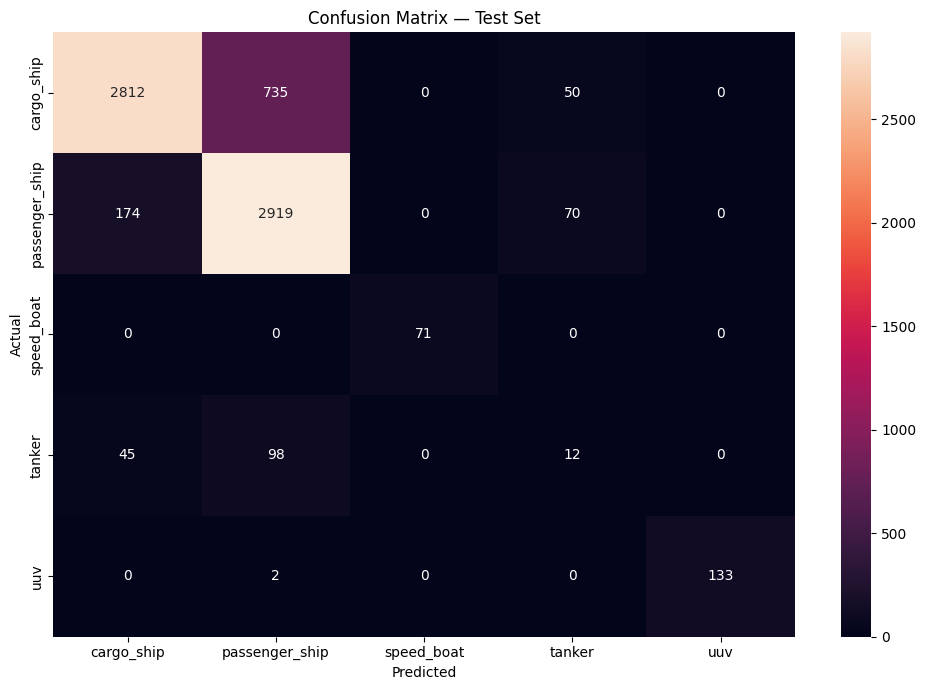

In [ ]:
# =========================
# EVALUATION ON TEST SET
# =========================
test_data   = np.load(os.path.join(SAVE_DIR, "test.npz"))
test_ds     = torch.utils.data.TensorDataset(
    torch.from_numpy(test_data["X"]).float(),
    torch.from_numpy(test_data["y"]).long()
)
test_loader = DataLoader(test_ds, batch_size=64)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

target_names = [idx_to_label[i] for i in label_list]
print("\n===== TEST SET RESULTS =====")
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()